<a href="https://colab.research.google.com/github/Riyaz127/TNS-Practice/blob/main/Batch2_day17(ML_2_Supervised_Learning).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Supervised Learning Other Algorithms:


In [1]:
#
from google.colab import files
uploaded=files.upload()

Saving Presentation-TASK - Sheet1.csv to Presentation-TASK - Sheet1.csv


In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [47]:
df=pd.read_csv('Presentation-TASK - Sheet1.csv')
df

,UID,Participant Name,Unnamed: 2,Project Name,Technical knowledge,Communication,Attrire,Marks
0,NaN,NaN,Group No,NaN,10,10.0,5.0,NaN
1,T160600201,Gayathri Munasu,3,"types of Data visuals,application",6,6.0,3.0,NaN
2,T160600202,Namratha Bajjuri,4,Comparision of t-SNE,6,6.0,4.0,NaN
3,T160600203,Nikitha Sambangi,NaN,NaN,NaN,NaN,NaN,NaN
4,T160600204,Akhil Reddy Komireddy,3,KNN,6,7.0,3.0,NaN
...,...,...,...,...,...,...,...,...
80,Group - 4,Hand gestures,NaN,NaN,NaN,NaN,NaN,NaN
81,NaN,distractions,NaN,NaN,NaN,NaN,NaN,NaN
82,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
83,Group - 5,need to distribute the concepts equally,NaN,NaN,NaN,NaN,NaN,NaN


In [49]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   UID                  71 non-null     object 
 1   Participant Name     77 non-null     object 
 2   Unnamed: 2           62 non-null     object 
 3   Project Name         36 non-null     object 
 4   Technical knowledge  61 non-null     object 
 5   Communication        57 non-null     float64
 6   Attrire              55 non-null     float64
 7   Marks                0 non-null      float64
dtypes: float64(3), object(5)
memory usage: 5.4+ KB


,0
UID,14
Participant Name,8
Unnamed: 2,23
Project Name,49
Technical knowledge,24
Communication,28
Attrire,30
Marks,85


In [50]:
df['Technical knowledge']=pd.to_numeric(df['Technical knowledge'],errors='coerce')

In [51]:
df=df.drop('Marks',axis=1)


In [52]:
df=df.dropna()

In [53]:
df.isnull().sum()

,0
UID,0
Participant Name,0
Unnamed: 2,0
Project Name,0
Technical knowledge,0
Communication,0
Attrire,0


In [54]:
df.describe()

,Technical knowledge,Communication,Attrire
count,36.000000,36.000000,36.000000
mean,6.138889,6.000000,3.805556
std,1.125110,1.069045,0.524783
min,3.000000,3.000000,3.000000
25%,6.000000,6.000000,3.750000
50%,6.000000,6.000000,4.000000
75%,7.000000,7.000000,4.000000
max,8.000000,7.000000,5.000000


In [55]:
df["Marks"]=df['Attrire']+df['Technical knowledge']+df['Communication']

In [56]:
df.describe()

,Technical knowledge,Communication,Attrire,Marks
count,36.000000,36.000000,36.000000,36.000000
mean,6.138889,6.000000,3.805556,15.944444
std,1.125110,1.069045,0.524783,2.190166
min,3.000000,3.000000,3.000000,10.000000
25%,6.000000,6.000000,3.750000,15.000000
50%,6.000000,6.000000,4.000000,16.000000
75%,7.000000,7.000000,4.000000,18.000000
max,8.000000,7.000000,5.000000,19.000000


In [59]:
median=df['Marks'].median()
df['Result']=np.where(df['Marks']>median,1,0)

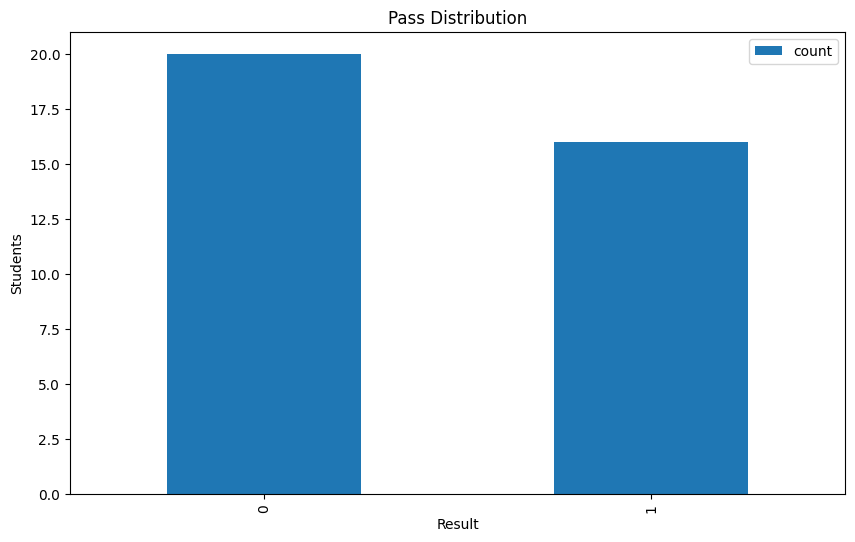

In [65]:
df['Result'].value_counts().plot(kind="bar",figsize=(10,6))
plt.title('Pass Distribution')
plt.ylabel('Students')
plt.legend()
plt.show()

/tmp/ipykernel_418/2793865009.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


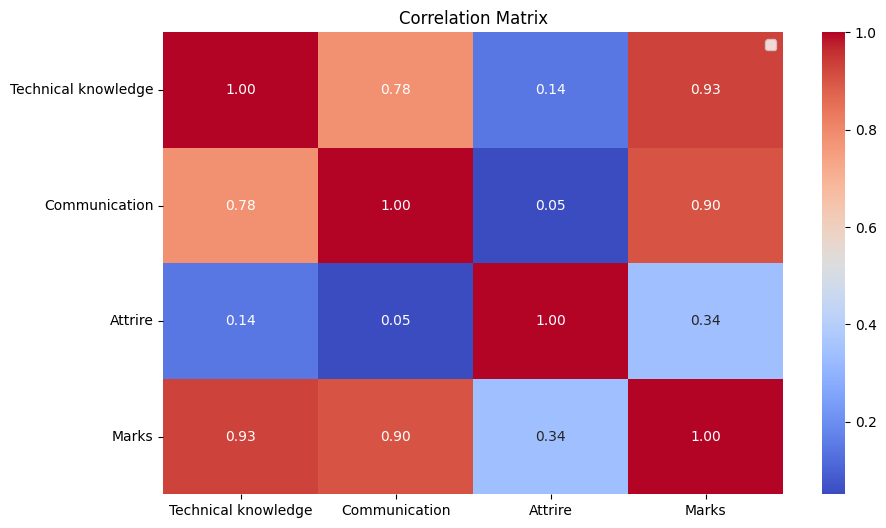

In [71]:
plt.figure(figsize=(10,6))
df1=df.drop('Result',axis=1)
sns.heatmap(
    df1.corr(numeric_only=True),annot=True,fmt='.2f',cmap='coolwarm'
)
plt.legend()
plt.title('Correlation Matrix')
plt.show()

In [72]:
#Feature and Target
X=df.drop('Result',axis=1)
y=df['Result']


In [73]:
#Encode Target
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()
y=le.fit_transform(y)

In [74]:
#Train and split
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [ ]:
#Standardisation
